<a href="https://colab.research.google.com/github/Vikrant25122004/Stock-Price-Prediction-Model/blob/main/Skin_disease_detection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()



Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vikrantsharma251111","key":"05ce06b9184db18884adde1cfb778ef4"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json



In [3]:
#!/bin/bash
!kaggle datasets download ismailpromus/skin-diseases-image-dataset

Dataset URL: https://www.kaggle.com/datasets/ismailpromus/skin-diseases-image-dataset
License(s): copyright-authors
100% 5.18G/5.19G [01:23<00:00, 52.6MB/s]
100% 5.19G/5.19G [01:23<00:00, 67.0MB/s]


In [4]:
import zipfile

zip_path = "/content/skin-diseases-image-dataset.zip"
output_dir = "/content/unzipped"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(output_dir)

In [9]:
import keras
import matplotlib.pyplot as plt

dataset = keras.utils.image_dataset_from_directory(
    directory="/content/unzipped/IMG_CLASSES",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128,128),
    color_mode="rgb",
)


Found 27153 files belonging to 10 classes.


In [10]:
def normal(image,label):
  return image/255,label

dataset_ds = dataset.map(normal)

In [12]:
!pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.9 MB/s eta 0:00:00


In [19]:
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from tensorflow.keras.layers import (
    Conv2D, Dense, BatchNormalization, MaxPooling2D,
    Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential


def buildmodel(hp):

    # Activation choices
    act_list = [
        "relu", "sigmoid", "tanh", "softplus", "softsign",
        "selu", "elu", "exponential", "linear", "gelu",
        "swish", "hard_sigmoid", "hard_swish"
    ]

    model = Sequential()

    # Block 1
    model.add(Conv2D(
        32, (3,3), padding='same',
        activation=hp.Choice("act1", act_list),
        input_shape=(128,128,3)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())

    # Block 2
    model.add(Conv2D(
        64, (3,3), padding='same',
        activation=hp.Choice("act2", act_list)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())

    # Block 3
    model.add(Conv2D(
        128, (3,3), padding='same',
        activation=hp.Choice("act3", act_list)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())

    # Block 4
    model.add(Conv2D(
        256, (3,3), padding='same',
        activation=hp.Choice("act4", act_list)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())

    model.add(Dropout(0.2))
    model.add(GlobalAveragePooling2D())

    # Dense Head
    model.add(Dense(
        256,
        activation=hp.Choice("dense_act", act_list)
    ))
    model.add(Dropout(0.2))

    # Output (always softmax)
    model.add(Dense(10, activation="softmax"))

    # Optimizer choices (valid in Keras)
    opt_name = hp.Choice(
        "optimizer",
        ["SGD", "RMSprop", "Adam", "AdamW", "Adagrad", "Adamax", "Nadam", "Ftrl"]
    )

    # map optimizer name to real object
    optimizer_dict = {
        "SGD": keras.optimizers.SGD(),
        "RMSprop": keras.optimizers.RMSprop(),
        "Adam": keras.optimizers.Adam(),
        "AdamW": keras.optimizers.AdamW(),
        "Adagrad": keras.optimizers.Adagrad(),
        "Adamax": keras.optimizers.Adamax(),
        "Nadam": keras.optimizers.Nadam(),
        "Ftrl": keras.optimizers.Ftrl(),
    }

    model.compile(
        optimizer=optimizer_dict[opt_name],
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [24]:
tuner = kt.RandomSearch(
    buildmodel,
    objective="val_accuracy",
    max_trials=5,
    executions_per_trial=1,
    directory="tuner_dir",
    project_name="skin_cnn"

)


Reloading Tuner from tuner_dir/skin_cnn/tuner0.json


In [28]:
model = tuner.get_best_models(1)[0]
model.fit(dataset_ds,epochs = 20)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 43 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


849/849 ━━━━━━━━━━━━━━━━━━━━ 111s 119ms/step - accuracy: 0.9041 - loss: 0.2636
Epoch 2/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 96s 113ms/step - accuracy: 0.9063 - loss: 0.2551
Epoch 3/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 94s 110ms/step - accuracy: 0.9072 - loss: 0.2507
Epoch 4/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 95s 111ms/step - accuracy: 0.9201 - loss: 0.2277
Epoch 5/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 94s 110ms/step - accuracy: 0.9240 - loss: 0.2082
Epoch 6/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 143s 111ms/step - accuracy: 0.9211 - loss: 0.2100
Epoch 7/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 94s 111ms/step - accuracy: 0.9361 - loss: 0.1899
Epoch 8/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 94s 111ms/step - accuracy: 0.9324 - loss: 0.1899
Epoch 9/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 143s 112ms/step - accuracy: 0.9343 - loss: 0.1789
Epoch 10/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 94s 110ms/step - accuracy: 0.9403 - loss: 0.1645
Epoch 11/20
849/849 ━━━━━━━━━━━━━━━━━━━━ 142s 110ms/step - accuracy: 0.9363 - loss: 0.1746
Epoch 12/20
849/849 ━━━━━━

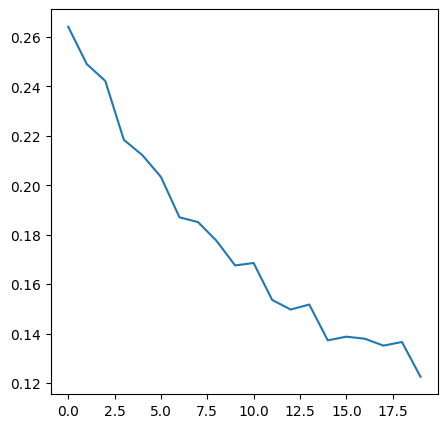

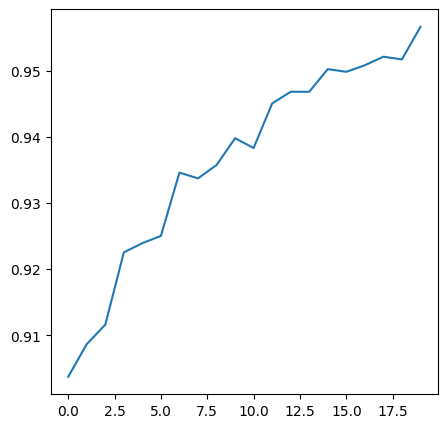

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.subplot(111)
plt.plot(model.history.history['loss'])
plt.show()
plt.figure(figsize=(5,5))
plt.subplot(111)
plt.plot(model.history.history['accuracy'])